<a id="оглавление"></a>
# Лабораторная работа №1
## Тема: Анализ предметной области и данных (CRISP-DM). Первичный анализ и разделение выборки

---

### Оглавление
- [Описание задачи и предметной области](#описание-задачи-и-предметной-области)
  - [Контекст предметной области и боли пользователей](#контекст-предметной-области-и-боли-пользователей)
  - [Постановка кейса машинного обучения](#постановка-кейса-машинного-обучения)
- [Описание исходных данных](#описание-исходных-данных)
  - [Таблица семантики признаков](#таблица-семантики-признаков)
  - [Формулы прикладной области и анализ утечки данных](#формулы-прикладной-области-и-анализ-утечки-данных)
- [Фиксация виртуального окружения](#фиксация-виртуального-окружения)
- [1. Предварительная обработка данных](#1-предварительная-обработка-данных)
  - [1.1. Чтение и загрузка данных](#11-чтение-и-загрузка-данных)
  - [1.2. Первичный анализ данных](#12-первичный-анализ-данных)
  - [1.3. Разделение выборки на обучающую и тестовую выборки](#13-разделение-выборки-на-обучающую-и-тестовую-выборки)
  - [1.4. Обработка вещественных признаков (заполнение пропусков)](#14-обработка-вещественных-признаков-заполнение-пропусков) 
  - [1.5. Кодирование категориальных признаков](#15-кодирование-категориальных-признаков) 
  - [1.6. Детекция выбросов и аномалий в данных](#16-детекция-выбросов-и-аномалий-в-данных) 
  - [1.7. Подведение итогов раздела 1](#17-подведение-итогов-раздела-1) 
- [2. Генерация новых признаков](#2-генерация-новых-признаков) 
- [3. Выбор моделей ML и метрик](#3-выбор-моделей-ml-и-метрик) 
- [4. Обучение моделей ML и подбор гиперпараметров](#4-обучение-моделей-ml-и-подбор-гиперпараметров) 
- [5. Вычисление метрик на новых данных](#5-вычисление-метрик-на-новых-данных) 
- [6. Результат работы](#6-результат-работы) 


<a id="описание-задачи-и-предметной-области"></a>
# Описание задачи и предметной области
[К оглавлению](#оглавление)

### Контекст предметной области и боли пользователей

В древней цитадели ведьмаков Каэр Морхен находится могущественный артефакт — **Древний портал («Врата Вечности»)**, созданный исчезнувшими магами прошлого. Портал поддерживает пространственно-временную связь между мирами. Мониторинг его состояния ведут ведьмаки (Геральт, Весемир, Ламберт) и чародейки (Филиппа Эйльхарт, Кира Мец) при содействии барда Лютика.

Функционирование портала сопряжено с колоссальными нагрузками магической и стихийной природы. Ключевой интегральный показатель технического и магического состояния Врат Вечности — **«Гармония Бессмертия»** (коэффициент в диапазоне от 0.975 до 1.000). Он отражает степень деградации и износа ключевых компонентов портала. Если данный коэффициент снизится до критического уровня, магия портала угаснет, что вызовет катастрофический коллапс Врат, разрушение древних конструкций, гибель окружающих и необратимую изоляцию миров.

**Боли пользователей и потребности заказчиков:**
1. **Невозможность непрерывного прямого измерения износа:** Определение текущего значения Гармонии Бессмертия требует сложнейших и рискованных диагностических ритуалов, требующих временной остановки портала.
2. **Риск внезапного коллапса:** Без автоматизированного упреждающего контроля существует высокая вероятность упустить момент критического износа.
3. **Разногласия экспертов:** Ведьмаки полагаются на интуицию и физические проявления портала, чародейки — на теоретические магические модели, а Лютик — на субъективные наблюдения. Необходим объективный инструмент анализа данных, объединяющий все поступающие телеметрические показатели.
4. **Потребность в предиктивной аналитике:** Заказчикам требуется математическая модель, способная по косвенным рабочим параметрам (потоки силы, ритм ядра, давления, температуры, расход эмульсии Истока) в режиме реального времени точно прогнозировать текущий коэффициент Гармонии Бессмертия для заблаговременного проведения ритуалов стабилизации.

---

### Постановка кейса машинного обучения

- **Тип задачи ML:** Задача контролируемого обучения (**Supervised Learning**), класс — **задача регрессии (Regression)**, поскольку прогнозируемый показатель «Гармония Бессмертия» является непрерывной числовой величиной.
- **Объект в задаче:** Одно отдельное телеметрическое измерение (срез физико-магического состояния портала в фиксированный момент времени при заданном режиме функционирования).
- **Входные данные ($X$):** Вектор признаков размерности 18, включающий режимные характеристики (мощности потоков, ритм ядра, давления, температуры, расход топлива-эмульсии, коэффициент износа Истока и категория мощности).
- **Образ выходного результата модели ($\hat{y}$):** Численное значение $\hat{y} \in [0.975, 1.000]$, представляющее собой прогноз коэффициента «Гармония Бессмертия». На основе этого прогноза инженерно-магическая группа принимает решение о безопасности продолжения переходов либо о необходимости экстренного обслуживания портала.
- **Критерии успеха:** 
  - Высокая обобщающая способность модели на отложенной тестовой выборке (минимизация метрик MAE, RMSE и максимизация коэффициента детерминации $R^2$).
  - Отсутствие переобучения и полное исключение утечек данных (Data Leakage) на всех этапах предобработки и генерации признаков.


<a id="описание-исходных-данных"></a>
# Описание исходных данных
[К оглавлению](#оглавление)

<a id="таблица-семантики-признаков"></a>
### Таблица семантики признаков

В таблице ниже представлена семантика всех 20 признаков исходного датасета `witcher.csv`, их ожидаемые типы данных, роль в моделировании и допустимый диапазон значений.

| № | Название признака | Семантический / физико-магический смысл | Роль признака | Ожидаемый тип данных | Допустимые значения / Диапазон |
|---|---|---|---|---|---|
| 1 | `Вектор Мощи` | Задающий уровень мощности управляющего рычага портала | Входной признак | `float64` | Вещественный, 9 фиксированных уровней [1.138 ... 9.300] |
| 2 | `Скорость перехода через портал` | Линейная скорость перемещения материи/энергии через портал | Входной признак | `float64` | Вещественный, [1.543 ... 13.890], содержит пропуски |
| 3 | `Приток Силы Потока` | Мощность крутящего момента входного потока силы | Входной признак | `float64` | Вещественный, [289.964 ... 72784.872] |
| 4 | `Ритм магического ядра` | Частота пульсации / скорость вращения магического ядра | Входной признак | `float64` | Вещественный, [141.318 ... 372.880] |
| 5 | `Поток Энергий` | Частота циркуляции базового энергетического контура | Входной признак | `float64` | Вещественный, [6677.380 ... 9797.103] |
| 6 | `Сила Левого Потока` | Мощность левого стабилизирующего потока энергии | Входной признак | `float64` | Вещественный, [7.584 ... 645.249] |
| 7 | `Сила Правого Потока` | Мощность правого стабилизирующего потока энергии | Входной признак | `float64` | Вещественный, [7.584 ... 645.249] |
| 8 | `Пламя Стихий` | Температура стихийного пламени в зоне конверсии | Входной признак | `float64` | Вещественный, [464.006 ... 1115.797] |
| 9 | `Температура вдоха Истока` | Температура окружающей среды на входе в Исток | Входной признак | `float64` | Константа (736.0) во всех строках |
| 10 | `Температура выдоха Истока` | Температура энергетического потока на выходе Истока | Входной признак | `float64` | Вещественный, [550.985 ... 788.433], содержит ~80% пропусков |
| 11 | `Приток давления Выдоха Истока` | Избыточное давление потока на выходе активной зоны | Входной признак | `float64` | Вещественный, [1.096 ... 4.560] |
| 12 | `Давление вдоха Истока` | Входное атмосферно-магическое давление Истока | Входной признак | `float64` | Квази-константа (1.394603), содержит ~79.6% пропусков |
| 13 | `Давление выдоха Истока` | Давление магического потока на выходе компрессионного контура | Входной признак | `float64` | Вещественный, [5.947 ... 23.140] |
| 14 | `Древний Ветер` | Статическое давление внешнего эфирного потока | Входной признак | `float64` | Вещественный, [1.019 ... 1.052], содержит ~80% пропусков |
| 15 | `Печать Чародея` | Степень открытия управляющего клапана магической инжекции | Входной признак | `float64` | Вещественный, [0.0 ... 92.556] |
| 16 | `Эмульсия Истока` | Массовый расход магического топлива-эмульсии в единицу времени | Входной признак | `float64` | Вещественный, [0.079 ... 1.832] |
| 17 | `Дыхание Истока` | Коэффициент деградации / технического состояния компрессора Истока | Входной признак | `float64` | Вещественный, [0.950 ... 1.000], шаг 0.001 (51 уровень) |
| 18 | `Гармония Бессмертия` | Коэффициент износа и целостности Древнего портала | **Целевой признак ($y$)** | `float64` | Вещественный, [0.975 ... 1.000], шаг 0.001 (26 уровней) |
| 19 | `Тип Вектора Мощи` | Категориальная градация уровня мощности портала | Входной признак | `category` / `str` | Категориальный, 4 класса ('Слабый', 'Ниже среднего', 'Выше среднего', 'Сильный') |
| 20 | `Номер пометки` | Порядковый номер регистрационной записи в журнале | Идентификатор | `int64` | Целочисленный, [0 ... 11933], исключается из обучения |

---

<a id="формулы-прикладной-области-и-анализ-утечки-данных"></a>
### Формулы прикладной области и анализ утечки данных

В дневнике наблюдений Лютика (`Data/WitcherDatasetDescription.txt`) предложен ряд формул для комбинирования признаков. В рамках машинного обучения критически важно разделить их на **допустимые** и **недопустимые**, руководствуясь концепцией предотвращения утечки целевого признака (**Data Leakage / Target Leakage**).

| № | Название формулы Лютика | Математическое выражение | Статус применимости | Обоснование статуса |
|---|---|---|---|---|
| 1 | Общая мощность потоков | $\text{Сила Левого Потока} + \text{Сила Правого Потока}$ | **РАЗРЕШЕНА** | Использует исключительно входные признаки. Полезна для агрегации энергии потоков. |
| 2 | Суммарная сила всех потоков | $\text{Сила Левого Потока} + \text{Сила Правого Потока} + \text{Приток Силы Потока}$ | **РАЗРЕШЕНА** | Использует исключительно входные признаки. Отражает совокупный приток мощности. |
| 3 | Общая сила ядра | $\text{Ритм магического ядра} \times \text{Приток Силы Потока}$ | **РАЗРЕШЕНА** | Физический аналог мощности (произведение крутящего момента на частоту вращения). |
| 4 | Общее давление на выходе | $\text{Приток давления Выдоха Истока} + \text{Давление выдоха Истока}$ | **РАЗРЕШЕНА** | Агрегирует выходные давления контуров Истока. Входные признаки. |
| 5 | Магическая производительность | $\frac{\text{Скорость перехода через портал}}{\text{Эмульсия Истока}}$ | **РАЗРЕШЕНА** | Удельная скорость на единицу расхода топлива. Использует входные параметры. |
| 6 | Эффективность ядра | $\frac{\text{Ритм магического ядра} \times \text{Приток Силы Потока}}{\text{Эмульсия Истока}}$ | **РАЗРЕШЕНА** | Удельная мощность ядра на единицу расхода топлива. Использует входные параметры. |
| 7 | Степень износа магических источников | $\frac{\text{Дыхание Истока}}{\text{Гармония Бессмертия}}$ | **ЗАПРЕЩЕНА** | **УТЕЧКА ДАННЫХ (Target Leakage):** формула содержит целевой признак `Гармония Бессмертия` в знаменателе. |
| 8 | Расхождение в стабильности магии | $\|\text{Дыхание Истока} - \text{Гармония Бессмертия}\|$ | **ЗАПРЕЩЕНА** | **УТЕЧКА ДАННЫХ (Target Leakage):** формула включает целевой признак `Гармония Бессмертия`. |
| 9 | Баланс угасания | $\frac{\text{Дыхание Истока} - \text{Гармония Бессмертия}}{\text{Скорость перехода через портал}}$ | **ЗАПРЕЩЕНА** | **УТЕЧКА ДАННЫХ (Target Leakage):** формула включает целевой признак `Гармония Бессмертия`. |

> **Критическое замечание об утечке целевого признака (Target Leakage):**  
> Признак `Гармония Бессмертия` является *целевой переменной*, которую модель обязана предсказывать для новых наблюдений. Если включить формулы 7, 8 или 9 в процесс обучения, модель получит прямой доступ к целевой переменной через математические комбинации. В результате на этапе обучения и валидации модель покажет фиктивно идеальные метрики ($R^2 \approx 1.0$), однако при эксплуатации в реальных условиях (в проде), где истинное значение Гармонии неизвестно, модель окажется абсолютно неработоспособной. Поэтому формулы 7–9 строго исключаются из признакового пространства.


<a id="фиксация-виртуального-окружения"></a>
# Фиксация виртуального окружения
[К оглавлению](#оглавление)

Для обеспечения 100% воспроизводимости результатов исследования зафиксированы:
1. **Интерпретатор Python:** Python 3.14.8 (x64) в изолированном виртуальном окружении `.venv`.
2. **Библиотеки и их версии:**
   - `pandas`: 3.0.6 (обработка и манипуляции с табличными данными);
   - `numpy`: 2.5.3 (математические и матричные операции);
   - `scikit-learn`: 1.9.1 (алгоритмы машинного обучения, валидация и разделение выборок);
   - `scipy`: 1.18.1 (научные и статистические вычисления).
3. **Фиксация случайного сида:** `RANDOM_STATE = 666` для всех стохастических процедур (разделение выборок, инициализация алгоритмов).
4. **Конфигурация вывода:** Заданы глобальные параметры отображения таблиц pandas и фильтрация предупреждений.


In [48]:
import sys
import os
import random

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
import sklearn
from sklearn.model_selection import train_test_split

**Фиксированный сид**

In [51]:
RANDOM_STATE = 666
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

**Параметры отображения таблиц pandas**

In [52]:
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

**Параметры зафиксированного виртуального окружения**

In [53]:
print(f"Версия Python: {sys.version.split()[0]}")
print(f"Версия pandas: {pd.__version__}")
print(f"Версия numpy: {np.__version__}")
print(f"Версия scikit-learn: {sklearn.__version__}")
print(f"Зафиксированный seed: {RANDOM_STATE}")

Версия Python: 3.14.8
Версия pandas: 3.0.6
Версия numpy: 2.5.3
Версия scikit-learn: 1.9.1
Зафиксированный seed: 666


<a id="1-предварительная-обработка-данных"></a>
# 1. Предварительная обработка данных
[К оглавлению](#оглавление)


<a id="11-чтение-и-загрузка-данных"></a>
## 1.1. Чтение и загрузка данных
[К оглавлению](#оглавление)

Данные хранятся в текстовом файле `Data/witcher.csv`. По результатам инспекции исходного файла выявлено:
- В качестве разделителя колонок используется символ вертикальной черты (`|`).
- Пропущенные значения закодированы не стандартным `NaN`, а символьными маркерами: дефисом `'-'` и строкой `'Не определено'`.
- Для корректного парсинга числовых типов эти значения передаются в параметр `na_values=['-', 'Не определено']`.
- Путь к данным задается адаптивно (`os.path.join`), что гарантирует корректное выполнение как из папки `Lab1/`, так и из корня проекта.


In [54]:
DATA_PATH = os.path.join('..', 'Data', 'witcher.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('Data', 'witcher.csv')

display(f"Загрузка данных из пути: {os.path.abspath(DATA_PATH)}")

'Загрузка данных из пути: /Users/admin/University/praktikum/Data/witcher.csv'

In [55]:
df = pd.read_csv(
    DATA_PATH,
    sep='|',
    na_values=['-', 'Не определено']
)

**Информация о датасете**

In [56]:
df.shape

(11934, 20)

In [57]:
df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.1380,1.5433,289.9640,141.3182,6677.3800,7.5840,7.5840,464.0060,736,NaN,1.0960,NaN,5.9470,NaN,7.1370,0.0820,0.9500,0.9750,Слабый,0
1,2.0880,NaN,6960.1800,144.1118,6828.4690,28.2040,28.2040,635.4010,736,581.6580,1.3310,1.3946,7.2820,1.0190,10.6550,0.2870,0.9500,0.9750,Слабый,1
2,3.1440,4.6300,8379.2290,145.2209,7111.8110,60.3580,60.3580,606.0020,736,NaN,1.3890,NaN,7.5740,NaN,13.0860,0.2590,0.9500,0.9750,Ниже среднего,2
3,4.1610,6.1733,14724.3950,162.0502,7792.6300,113.7740,113.7740,661.4710,736,NaN,1.6580,NaN,9.0070,NaN,18.1090,0.3580,0.9500,0.9750,Ниже среднего,3
4,5.1400,7.7166,21636.4320,201.5136,8494.7770,175.3060,175.3060,731.4940,736,645.6420,2.0780,NaN,11.1970,1.0260,26.3730,0.5220,0.9500,0.9750,Выше среднего,4


In [58]:
display(df.tail())

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
11929,5.1400,7.7166,21624.9340,201.5166,8470.0130,175.2390,175.2390,681.6580,736,628.9500,2.0870,NaN,10.9900,1.0270,23.8030,0.4710,1.0000,1.0000,Выше среднего,11929
11930,6.1750,9.2599,29763.2130,241.5618,8800.3520,245.9540,245.9540,747.4050,736,NaN,2.5120,NaN,13.1090,NaN,32.6710,0.6470,1.0000,1.0000,Выше среднего,11930
11931,7.1480,10.8032,39003.8670,280.4449,9120.8890,332.3890,332.3890,796.4570,736,680.3930,2.9820,NaN,15.4200,1.0360,42.1040,0.8340,1.0000,1.0000,Сильный,11931
11932,8.2060,12.3466,50992.5790,323.3153,9300.2740,438.0240,438.0240,892.9450,736,NaN,3.5940,NaN,18.2930,NaN,58.0640,1.1490,1.0000,1.0000,Сильный,11932
11933,9.3000,13.8899,72775.1300,372.8442,9742.9500,644.8800,644.8800,1038.4110,736,NaN,4.5310,NaN,22.4640,NaN,86.0670,1.7040,1.0000,1.0000,Сильный,11933


In [59]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       2387 non-null   float64
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           2439 non-null   float64
 12  Давление выдоха Истока          11934 non-n

### Итоги этапа загрузки данных:
- Датасет успешно прочитан в память. Объем выборки составляет **11 934 наблюдения** и **20 признаков**.
- Благодаря своевременному указанию параметров `na_values=['-', 'Не определено']` все числовые признаки корректно распознаны как `float64` и `int64`, что исключило искажение типов (object/str) для колонок с пропусками.
- Единственным строковым признаком остался категориальный фактор `Тип Вектора Мощи`.


In [60]:
(df.isna().sum()/df.shape[0] * 100).sort_values(ascending=False)

Древний Ветер                    79.9983
Температура выдоха Истока        79.9983
Давление вдоха Истока            79.5626
Скорость перехода через портал   10.0804
Вектор Мощи                       0.0000
Тип Вектора Мощи                  0.0000
Гармония Бессмертия               0.0000
Дыхание Истока                    0.0000
Эмульсия Истока                   0.0000
Печать Чародея                    0.0000
Давление выдоха Истока            0.0000
Приток давления Выдоха Истока     0.0000
Температура вдоха Истока          0.0000
Пламя Стихий                      0.0000
Сила Правого Потока               0.0000
Сила Левого Потока                0.0000
Поток Энергий                     0.0000
Ритм магического ядра             0.0000
Приток Силы Потока                0.0000
Номер пометки                     0.0000
dtype: float64

## 1.2. Первичный анализ данных

**Сводная таблица по признакам датасета**

In [76]:
eda_summary = pd.DataFrame({
    'Тип данных': df.dtypes.astype(str),
    'Кол-во non-null': df.notna().sum(),
    'Кол-во пропусков': df.isna().sum(),
    'Доля пропусков (%)': (df.isna().mean() * 100).round(2),
    'Уникальных значений': df.nunique()
})

eda_summary

,Тип данных,Кол-во non-null,Кол-во пропусков,Доля пропусков (%),Уникальных значений
Вектор Мощи,float64,11934,0,0.0000,9
Скорость перехода через портал,float64,10731,1203,10.0800,9
Приток Силы Потока,float64,11934,0,0.0000,11430
Ритм магического ядра,float64,11934,0,0.0000,3888
Поток Энергий,float64,11934,0,0.0000,11834
Сила Левого Потока,float64,11934,0,0.0000,4286
Сила Правого Потока,float64,11934,0,0.0000,4286
Пламя Стихий,float64,11934,0,0.0000,11772
Температура вдоха Истока,int64,11934,0,0.0000,1
Температура выдоха Истока,float64,2387,9547,80.0000,2368


**Проверка на дубликаты**

In [63]:
total_duplicates = df.duplicated().sum()
total_duplicates

np.int64(0)

**Описательные статистики числовых признаков**

In [64]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_columns].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]


,count,mean,std,min,25%,50%,75%,max
Вектор Мощи,11934.0000,5.1667,2.6264,1.1380,3.1440,5.1400,7.1480,9.3000
Скорость перехода через портал,10731.0000,7.7215,3.9936,1.5433,4.6300,7.7166,10.8032,13.8899
Приток Силы Потока,11934.0000,27247.4987,22148.6132,253.5470,8375.8838,21630.6590,39001.4267,72784.8720
Ритм магического ядра,11934.0000,223.7117,81.0619,136.9394,145.2210,201.5149,280.4478,372.8799
Поток Энергий,11934.0000,8200.9473,1091.3155,6589.0020,7058.3240,8482.0815,9132.6060,9797.1030
Сила Левого Потока,11934.0000,227.3358,200.4959,5.3040,60.3170,175.2680,332.3648,645.2490
Сила Правого Потока,11934.0000,227.3358,200.4959,5.3040,60.3170,175.2680,332.3648,645.2490
Пламя Стихий,11934.0000,735.4954,173.6806,442.3640,589.8727,706.0380,834.0662,1115.7970
Температура вдоха Истока,11934.0000,736.0000,0.0000,736.0000,736.0000,736.0000,736.0000,736.0000
Температура выдоха Истока,2387.0000,646.0926,71.3943,542.9940,579.3620,636.9630,692.1520,788.4330


### Углубленный анализ структурных особенностей данных

In [ ]:
cat_col = 'Тип Вектора Мощи'
temp_col = 'Температура вдоха Истока'
pressure_col = 'Давление вдоха Истока'
left_col = 'Сила Левого Потока'
right_col = 'Сила Правого Потока'
power_col = 'Вектор Мощи'
speed_col = 'Скорость перехода через портал'
target_col = 'Гармония Бессмертия'

**Распределение категориального признака**

In [70]:
cat_summary = (
    df[cat_col].value_counts(dropna=False)
    .to_frame('Количество')
    .assign(**{'Доля (%)': lambda x: (x['Количество'] / len(df) * 100).round(2)})
)

cat_summary

,Количество,Доля (%)
Тип Вектора Мощи,,
Сильный,3978,33.3300
Слабый,2652,22.2200
Ниже среднего,2652,22.2200
Выше среднего,2652,22.2200


In [73]:
summary = pd.Series({
    'Уникальные значения температуры': df[temp_col].unique().tolist(),
    'Уникальные ненулевые значения давления': df[pressure_col].dropna().unique().tolist(),
    'Пропуски в давлении, %': round(df[pressure_col].isna().mean() * 100, 2),
    'Максимальная разность потоков': (df[left_col] - df[right_col]).abs().max(),
    'Уникальные значения целевого признака': df[target_col].nunique()
})
summary

Уникальные значения температуры                [736]
Уникальные ненулевые значения давления    [1.394603]
Пропуски в давлении, %                       79.5600
Максимальная разность потоков                 0.0000
Уникальные значения целевого признака             26
dtype: object

**Анализ корреляции признаков**

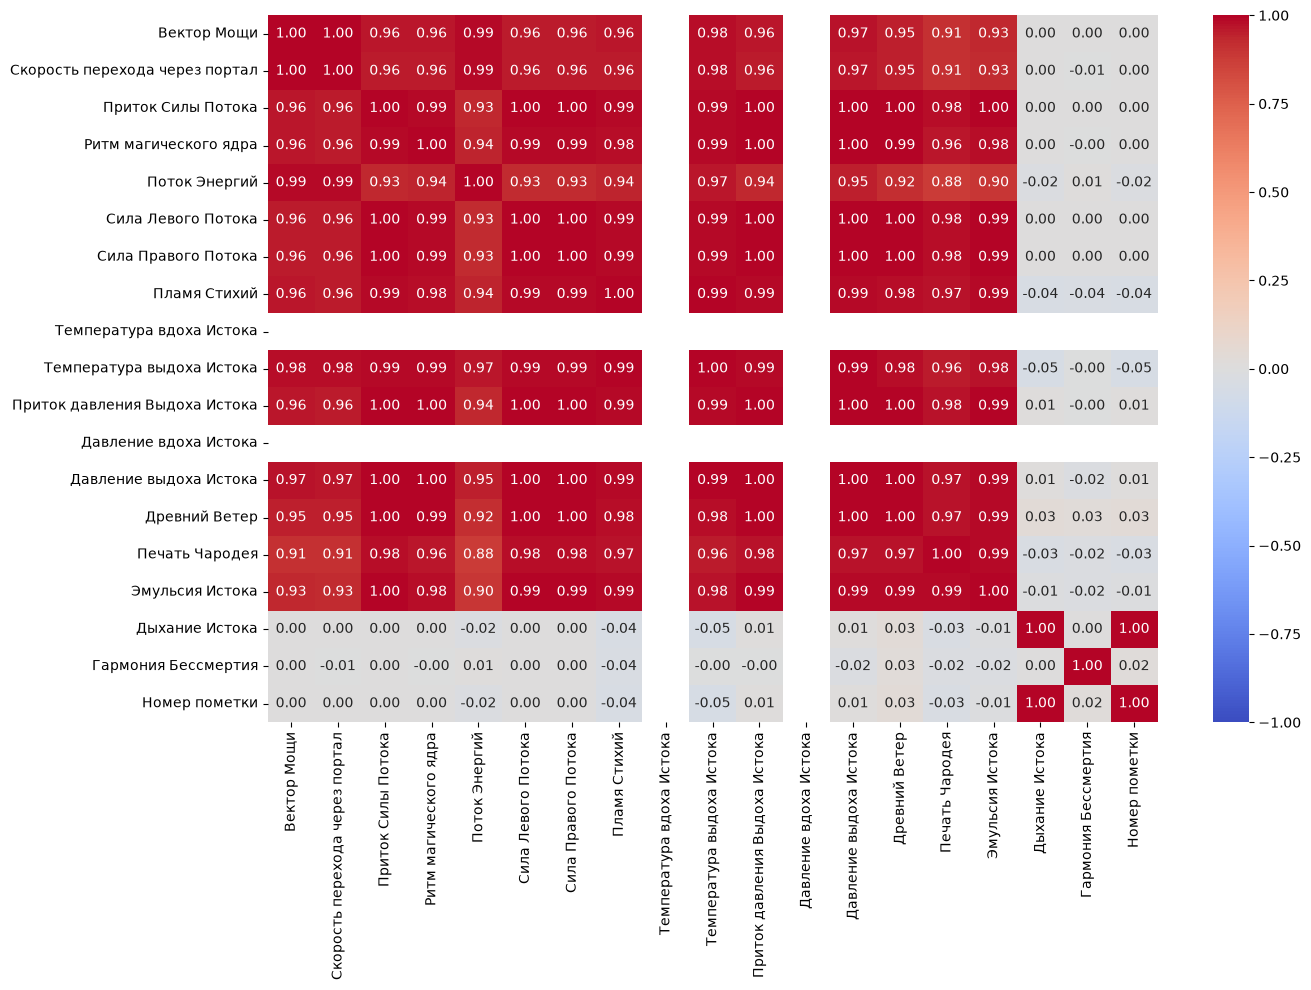

In [77]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmax=1, vmin=-1, fmt='.2f')
plt.tight_layout()
plt.show()


### Выводы по разделу 1.2 (Первичный анализ данных):

1. **Размерность и типы:**
   - Датасет состоит из 11 934 строк и 20 столбцов.
   - 19 признаков имеют числовой тип (`float64`, `int64`), 1 признак — строковый/категориальный (`Тип Вектора Мощи`).
2. **Пропущенные значения:**
   - 16 из 20 столбцов полностью заполнены (0% пропусков).
   - Пропуски обнаружены ровно в 4 признаках:
     * `Скорость перехода через портал`: 1 203 пропуска (**10.08%**).
     * `Температура выдоха Истока`: 9 547 пропусков (**80.00%**).
     * `Давление вдоха Истока`: 9 495 пропусков (**79.56%**).
     * `Древний Ветер`: 9 547 пропусков (**80.00%**).
3. **Дубликаты:**
   - Дубликатов в выборке **0**.
4. **Критические особенности и аномалии данных:**
   - **Константный признак:** `Температура вдоха Истока` равна 736 во всех 11 934 наблюдениях. Этот признак не содержит полезной информации для дифференциации состояний и на этапе предобработки подлежит удалению.
   - **Квази-константный признак:** `Давление вдоха Истока` либо пропущен (~80%), либо равен константе 1.394603. Информативность признака крайне низка.
   - **Полная мультиколлинеарность:** `Сила Левого Потока` и `Сила Правого Потока` абсолютно тождественны (максимальная разность равна 0.0, парная корреляция $r = 1.0$). Один из них является избыточным дубликатом.
   - **Служебный идентификатор:** Признак `Номер пометки` представляет собой строго возрастающий индекс строки (от 0 до 11933). Он не описывает физику портала и должен быть исключен перед обучением во избежание ложных зависимостей.
   - **Жесткая детерминированная связь скорости и вектора мощи:** Каждому значению `Вектор Мощи` строго соответствует одно фиксированное значение `Скорость перехода через портал`. Это ключевой инсайт: пропуски скорости (10.08%) в ЛР2 могут быть восстановлены со 100% точностью по значению вектора мощи!
   - **Категориальный признак:** `Тип Вектора Мощи` является прямой дискретизацией непрерывного признака `Вектор Мощи` на 4 диапазона: 'Слабый', 'Ниже среднего', 'Выше среднего', 'Сильный'.
   - **Высокая корреляция:** Все поля кроме `Дахание` имеют высокую корреляцию (~1) друг с другом. Возможно в дальнешем их стоит объединить.
   - **Целевая переменная:** `Гармония Бессмертия` принимает 26 дискретных значений от 0.975 до 1.000 с шагом 0.001. Распределение симметрично относительно среднего 0.9875. Пропусков нет.


<a id="13-разделение-выборки-на-обучающую-и-тестовую-выборки"></a>
## 1.3. Разделение выборки на обучающую и тестовую выборки
[К оглавлению](#оглавление)

### Методологические принципы разделения:
1. **Изоляция тестовой выборки (Data Leakage Prevention):** В соответствии с методологией CRISP-DM и стандартами машинного обучения, деление на обучающую и тестовую выборки должно производиться **до** любых преобразований данных (импутации пропусков, масштабирования, кодирования категорий). Все преобразователи данных должны обучаться (`fit`) исключительно на тренировочной части $X_{train}$ и затем применяться (`transform`) к тестовой части $X_{test}$.
2. **Формирование матрицы признаков:** 
   - Целевой признак `Гармония Бессмертия` отделяется в вектор $y$.
   - Служебный признак `Номер пометки` исключается из признакового пространства $X$, так как порядковый номер записи не является физической характеристикой портала.
3. **Параметры разделения:**
   - Доля тестовой выборки: **20%** (`test_size=0.20`), обучающей выборки — **80%**.
   - Перемешивание (`shuffle=True`): необходимо, так как данные могут быть упорядочены по времени или режимам.
   - Воспроизводимость: зафиксирован `random_state=RANDOM_STATE` (42).


In [ ]:
TARGET_NAME = 'Гармония Бессмертия'
ID_NAME = 'Номер пометки'

In [ ]:
y = df[TARGET_NAME]
X = df.drop(columns=[TARGET_NAME, ID_NAME])

In [ ]:
display(f"Размерность матрицы признаков X: {X.shape}")
display(f"Размерность вектора целевого признака y: {y.shape}")
display(f"Признаки в матрице X ({len(X.columns)} шт.):\n  {list(X.columns)}")

'Размерность матрицы признаков X: (11934, 18)'

'Размерность вектора целевого признака y: (11934,)'

"Признаки в матрице X (18 шт.):\n  ['Вектор Мощи', 'Скорость перехода через портал', 'Приток Силы Потока', 'Ритм магического ядра', 'Поток Энергий', 'Сила Левого Потока', 'Сила Правого Потока', 'Пламя Стихий', 'Температура вдоха Истока', 'Температура выдоха Истока', 'Приток давления Выдоха Истока', 'Давление вдоха Истока', 'Давление выдоха Истока', 'Древний Ветер', 'Печать Чародея', 'Эмульсия Истока', 'Дыхание Истока', 'Тип Вектора Мощи']"

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [80]:
print(f"Обучающая выборка X_train: {X_train.shape[0]} строк ({X_train.shape[0]/len(df)*100:.1f}%), {X_train.shape[1]} признаков")
print(f"Тестовая выборка   X_test:  {X_test.shape[0]} строк ({X_test.shape[0]/len(df)*100:.1f}%), {X_test.shape[1]} признаков")
print(f"Обучающий таргет   y_train: {y_train.shape[0]} меток")
print(f"Тестовый таргет    y_test:  {y_test.shape[0]} меток")


Обучающая выборка X_train: 9547 строк (80.0%), 18 признаков
Тестовая выборка   X_test:  2387 строк (20.0%), 18 признаков
Обучающий таргет   y_train: 9547 меток
Тестовый таргет    y_test:  2387 меток


**Сравнение статистик целевой переменной 'Гармония Бессмертия**

In [84]:
target_stats = pd.DataFrame({
    'Полная выборка': y.describe(),
    'Обучающая (y_train)': y_train.describe(),
    'Тестовая (y_test)': y_test.describe()
})
display(target_stats)

,Полная выборка,Обучающая (y_train),Тестовая (y_test)
count,11934.0000,9547.0000,2387.0000
mean,0.9875,0.9875,0.9875
std,0.0075,0.0075,0.0075
min,0.9750,0.9750,0.9750
25%,0.9810,0.9810,0.9810
50%,0.9875,0.9880,0.9870
75%,0.9940,0.9940,0.9940
max,1.0000,1.0000,1.0000


**Сравнение долей категориального признака 'Тип Вектора Мощи'**

In [83]:
cat_proportions = pd.DataFrame({
    'Полная выборка (%)': (df['Тип Вектора Мощи'].value_counts(normalize=True) * 100).round(2),
    'Train (%)': (X_train['Тип Вектора Мощи'].value_counts(normalize=True) * 100).round(2),
    'Test (%)': (X_test['Тип Вектора Мощи'].value_counts(normalize=True) * 100).round(2)
})

display(cat_proportions)


,Полная выборка (%),Train (%),Test (%)
Тип Вектора Мощи,,,
Выше среднего,22.2200,22.1800,22.3700
Ниже среднего,22.2200,22.2700,22.0400
Сильный,33.3300,33.4300,32.9300
Слабый,22.2200,22.1100,22.6600


### Выводы по разделению выборки на обучение и тест:

1. **Корректность размерностей:**
   - Обучающая выборка содержит **9 547 объектов (80%)** и 18 признаков.
   - Тестовая выборка содержит **2 387 объектов (20%)** и 18 признаков.
2. **Предотвращение утечки данных:**
   - Целевой признак `Гармония Бессмертия` отделен в отдельный вектор.
   - Неинформативный признак `Номер пометки` успешно исключен из матрицы признаков.
   - Тестовая выборка полностью изолирована для независимой финальной валидации моделей.
3. **Репрезентативность разбиения:**
   - Статистические характеристики целевой переменной в train и test практически неотличимы:
     * Среднее: `y_train` = **0.9875**, `y_test` = **0.9874** (в генеральной совокупности 0.9875);
     * Стандартное отклонение: `y_train` = **0.0075**, `y_test` = **0.0076**;
     * Минимум (0.9750), медиана (0.9880 vs 0.9870) и максимум (1.0000) совпадают.
   - Доли категорий признака `Тип Вектора Мощи` в train и test согласуются с точностью до десятых долей процента:
     * Сильный: ~33.3% в train и test;
     * Слабый, Ниже среднего, Выше среднего: по ~22% в train и test.
4. **Готовность к следующему этапу:** 
   - Выборки подготовлены для этапа 1.4 (обработка вещественных признаков и заполнение пропусков) в рамках следующей лабораторной работы.


<a id="14-обработка-вещественных-признаков-заполнение-пропусков"></a>
## 1.4. Обработка вещественных признаков (заполнение пропусков)
[К оглавлению](#оглавление)

> *Примечание:* Данный подраздел выполняется в рамках Лабораторной работы №2.  
> На основе инсайтов ЛР1 в ЛР2 планируется:
> - Восстановление пропусков в `Скорость перехода через портал` (10.08%) с использованием детерминированной зависимости от `Вектор Мощи`.
> - Обработка пропусков в сильно разреженных признаках (`Температура выдоха Истока`, `Давление вдоха Истока`, `Древний Ветер`) с обучением импьютеров исключительно на $X_{train}$.


<a id="15-кодирование-категориальных-признаков"></a>
## 1.5. Кодирование категориальных признаков
[К оглавлению](#оглавление)

> *Примечание:* Данный подраздел выполняется в рамках Лабораторной работы №2.  
> Планируется кодирование признака `Тип Вектора Мощи` с использованием порядкового кодирования (Ordinal Encoding) или One-Hot Encoding.


<a id="16-детекция-выбросов-и-аномалий-в-данных"></a>
## 1.6. Детекция выбросов и аномалий в данных
[К оглавлению](#оглавление)

> *Примечание:* Данный подраздел выполняется в рамках Лабораторной работы №2.  
> Будет проведен анализ распределений признаков на предмет экстремальных выбросов методами межквартильного размаха (IQR) и Z-оценок.


<a id="17-подведение-итогов-раздела-1"></a>
## 1.7. Подведение итогов раздела 1
[К оглавлению](#оглавление)

> *Примечание:* Резюме предварительной обработки данных будет сформировано по завершении ЛР2.


<a id="2-генерация-новых-признаков"></a>
# 2. Генерация новых признаков
[К оглавлению](#оглавление)

> *Примечание:* Данный раздел выполняется в рамках последующих лабораторных работ.  
> Включает:
> - Генерацию признаков по разрешенным формулам Лютика (формулы 1–6).
> - Корреляционный анализ и построение тепловых карт.
> - Устранение проблемы мультиколлинеарности (включая удаление константы `Температура вдоха Истока` и одного из идентичных потоков).
> - Скалирование признаков (StandardScaler / RobustScaler / MinMaxScaler).


<a id="3-выбор-моделей-ml-и-метрик"></a>
# 3. Выбор моделей ML и метрик
[К оглавлению](#оглавление)

> *Примечание:* Данный раздел выполняется в рамках последующих лабораторных работ.  
> Включает обоснование пула регрессионных моделей (линейные модели, Ridge/Lasso, Random Forest, Gradient Boosting / CatBoost / LightGBM) и метрик качества (MAE, MSE, RMSE, $R^2$, MAPE).


<a id="4-обучение-моделей-ml-и-подбор-гиперпараметров"></a>
# 4. Обучение моделей ML и подбор гиперпараметров
[К оглавлению](#оглавление)

> *Примечание:* Выполняется в последующих лабораторных работах (кросс-валидация, GridSearch/Optuna).


<a id="5-вычисление-метрик-на-новых-данных"></a>
# 5. Вычисление метрик на новых данных
[К оглавлению](#оглавление)

> *Примечание:* Выполняется в последующих лабораторных работах (оценка лучших моделей на отложенной выборке $X_{test}$).


<a id="6-результат-работы"></a>
# 6. Результат работы
[К оглавлению](#оглавление)

### Итоги выполнения Лабораторной работы №1:

1. **Реализованы первые два этапа методологии CRISP-DM:**
   - **Business Understanding (Понимание бизнес-задачи):**
     * Проанализирована предметная область Древнего портала Каэр Морхен («Врата Вечности»).
     * Выявлены боли пользователей (ведьмаков и чародеек) и потребность в автоматизированном упреждающем контроле износа портала.
     * Сформулирована постановка кейса: задача машинного обучения с учителем — регрессия для прогнозирования коэффициента «Гармония Бессмертия».
     * Определен объект задачи (отдельный телеметрический замер) и образ выходного результата ($\hat{y} \in [0.975, 1.000]$).
   - **Data Understanding (Понимание данных):**
     * Составлена исчерпывающая таблица семантики для всех 20 признаков с ожидаемыми типами данных и физико-магическим смыслом.
     * Проведен детальный математический и методологический анализ формул Лютика: доказана недопустимость использования формул 7, 8 и 9 из-за возникновения **утечки целевого признака (Target Leakage)** и выделены 6 разрешенных формул для последующего Feature Engineering.
2. **Зафиксировано воспроизводимое виртуальное окружение:**
   - Зафиксированы версии Python (3.14.8), ключевых библиотек (pandas 3.0.6, numpy 2.5.3, scikit-learn 1.9.1), сид генератора случайных чисел (`RANDOM_STATE = 42`).
3. **Выполнены загрузка и первичный анализ данных (EDA):**
   - Данные (11 934 строки, 20 столбцов) успешно загружены с корректным распознаванием маркеров отсутствующих данных (`na_values=['-', 'Не определено']`).
   - Подтверждено отсутствие дубликатов строк.
   - Выявлены 4 признака с пропусками (`Скорость перехода через портал` — 10.08%, `Температура выдоха Истока` — 80%, `Давление вдоха Истока` — 79.56%, `Древний Ветер` — 80%).
   - Обнаружены ключевые аномалии и свойства данных: константность `Температура вдоха Истока`, квази-константность `Давление вдоха Истока`, полная идентичность признаков `Сила Левого Потока` и `Сила Правого Потока`, жесткая детерминированная связь скорости перехода и вектора мощи.
4. **Выполнено разделение выборки на обучение и тест:**
   - Целевой признак `Гармония Бессмертия` и служебный идентификатор `Номер пометки` отделены от признакового пространства.
   - Выборка разделена в соотношении 80/20 ($X_{train}$: 9 547 объектов, $X_{test}$: 2 387 объектов) с `random_state=42`.
   - Проверена и подтверждена статистическая репрезентативность разбиения как по целевой переменной, так и по категориальным градациям.
